In [ ]:
#NE POKRECI
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

class QuickDraw0Dataset(Dataset):
    def __init__(self, input_dir, target_dir, transform=None):
        self.input_dir = input_dir
        self.target_dir = target_dir
        self.transform = transform
        self.input_files = [f for f in os.listdir(input_dir) if f.endswith('.png')]
    
    def __len__(self):
        return len(self.input_files)
    
    def __getitem__(self, idx):
        input_file = self.input_files[idx]
        target_file = input_file.replace('my_', '')
        
        input_path = os.path.join(self.input_dir, input_file)
        target_path = os.path.join(self.target_dir, target_file)
        
        input_image = Image.open(input_path).convert("RGB")
        target_image = Image.open(target_path).convert("RGB")
        
        '''
        if self.transform:
            input_image = self.transform(input_image)
            target_image = self.transform(target_image)
        '''
        
        return input_image, target_image

In [46]:
import os
from PIL import Image
from torch.utils.data import Dataset

class QuickDraw0Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self.idx_to_class = {}  # novo: mapiranje indeks → naziv
        self.classes = []       # novo: lista imena klasa

        # Pronađi sve klase (nazive foldera)
        for idx, class_name in enumerate(sorted(os.listdir(root_dir))):
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                self.class_to_idx[class_name] = idx
                self.idx_to_class[idx] = class_name
                self.classes.append(class_name)
                for fname in os.listdir(class_path):
                    if fname.endswith(('.png', '.jpg', '.jpeg')):
                        self.samples.append((os.path.join(class_path, fname), class_name))  # ovde dodaješ naziv klase

    def __len__(self):
        return len(self.samples)

    '''
    def __getitem__(self, idx):
        image_path, class_name = self.samples[idx]
        image = Image.open(image_path).convert('L')
        if self.transform:
            image = self.transform(image)
        return image, class_name  # vraćamo naziv klase kao label
    '''
    
    def __getitem__(self, idx):
        image_path, class_name = self.samples[idx]
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.class_to_idx[class_name]  # vrati int umesto string
        return image, label




In [55]:
#JOS MANJI DATASET 3 KLASE

import torchvision.transforms as transforms
transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = QuickDraw0Dataset('balanced_chosen_3_images_preprocessed0', transform=transform)

In [47]:
import torchvision.transforms as transforms
transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = QuickDraw0Dataset('balanced_chosen_10_images_preprocessed0', transform=transform)

In [ ]:
#NE POKRECI

# Definiši transformacije (ako je potrebno)
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Inicijalizuj dataset
input_dir = ''
target_dir = ''
dataset = QuickDraw0Dataset(input_dir, target_dir, transform=transform)

In [22]:
from torch.utils.data import Subset


def create_subset(dataset, fraction=0.25):
    total_size = len(dataset)
    subset_size = int(total_size * fraction)
    
    indices = list(range(total_size))
    subset_indices = indices[:subset_size]
    
    return Subset(dataset, subset_indices)


subset_dataset = create_subset(dataset, fraction=0.25)

In [56]:
from torch.utils.data import Dataset, DataLoader, random_split

# Podeli dataset na trening (70%), validacioni (15%) i test set (15%)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

In [57]:
# Kreiraj DataLoader-e
batchsize = 64
train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batchsize, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batchsize, shuffle=False)

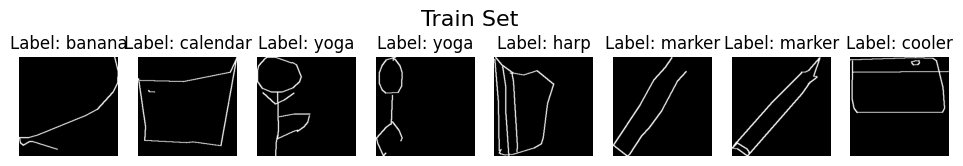

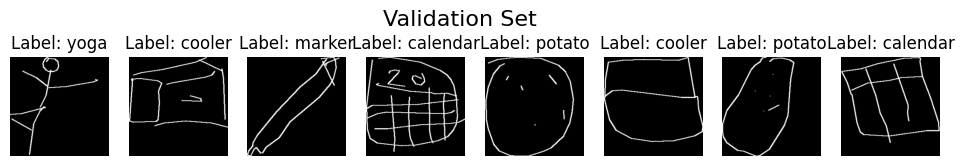

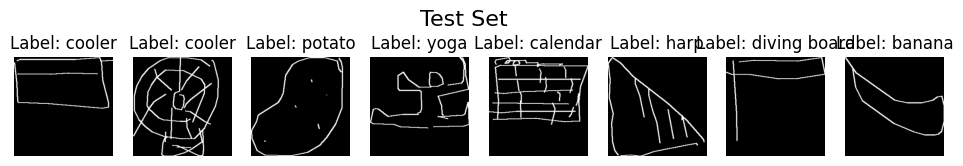

In [28]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

def show_batch(data_loader, title=""):
    images, labels = next(iter(data_loader))
    images = images[:8]  # prikaz samo 8 slika

    fig, axs = plt.subplots(1, 8, figsize=(12, 2))
    fig.suptitle(title, fontsize=16)

    for i in range(len(images)):
        img = images[i].squeeze().numpy()  # ako je grayscale
        axs[i].imshow(img, cmap='gray')
        
        #image, label = dataset[0]
        #class_name = dataset.classes[label]
        axs[i].set_title(f"Label: {labels[i]}")
        axs[i].axis('off')

    plt.show()


# Prikaz slika
show_batch(train_loader, title="Train Set")
show_batch(val_loader, title="Validation Set")
show_batch(test_loader, title="Test Set")


In [30]:
import torch
import torchvision.models as models
import torch.nn as nn

In [31]:
# Load pre-trained VGG16 model
model = models.vgg16(pretrained=True)
# Print the model architecture
print(model)

c:\Users\Stankovic\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Stankovic\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Stankovic/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [22:33<00:00, 409kB/s]   


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [58]:
# Replace the classifier of the VGG16 model
model.classifier[6] = nn.Linear(in_features=4096, out_features=3)
# Print the modified model
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [59]:
# Freeze all layers except the classifier
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

In [60]:
# Set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [62]:
print(device)  # treba da ispiše "cuda"


cpu


In [64]:
import torch.optim as optim

os.makedirs("saved_models_top3_vgg_0", exist_ok=True)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.classifier.parameters(), lr=0.001, momentum=0.9)
# Training loop
for epoch in range(10):  # Run for 10 epochs
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    print(f'Epoch [{epoch+1}/10], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct / total:.2f}%')
    model_path = f"saved_models/model_epoch_{epoch+1}.pth"
    torch.save(model.state_dict(), model_path)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for input_image, target_image in val_loader:
            input_image = input_image.to(device)
            target_image = target_image.to(device)
            outputs = model(input_image)
            loss = criterion(outputs, target_image)
            val_loss += loss.item()

    print(f"Validation Loss: {val_loss/len(val_loader)}")

Epoch [1/10], Loss: 0.1607, Accuracy: 94.43%
Validation Loss: 0.08180431136861444
Epoch [2/10], Loss: 0.1196, Accuracy: 96.10%
Validation Loss: 0.07153462572023273
Epoch [3/10], Loss: 0.1019, Accuracy: 97.05%
Validation Loss: 0.0639758863253519
Epoch [4/10], Loss: 0.0912, Accuracy: 97.00%
Validation Loss: 0.0674064438790083
Epoch [5/10], Loss: 0.0880, Accuracy: 97.14%
Validation Loss: 0.07237295247614384
Epoch [6/10], Loss: 0.0821, Accuracy: 97.71%
Validation Loss: 0.05582349107135087
Epoch [7/10], Loss: 0.0730, Accuracy: 97.95%
Validation Loss: 0.056718300096690655
Epoch [8/10], Loss: 0.0649, Accuracy: 97.86%
Validation Loss: 0.05628918146248907
Epoch [9/10], Loss: 0.0575, Accuracy: 98.62%
Validation Loss: 0.05760265374556184
Epoch [10/10], Loss: 0.0624, Accuracy: 98.33%
Validation Loss: 0.05437926255399361


In [ ]:
import torch.optim as optim

os.makedirs("saved_models_top3_vgg_0", exist_ok=True)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.classifier.parameters(), lr=0.001, momentum=0.9)
# Training loop
for epoch in range(10):  # Run for 10 epochs
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    print(f'Epoch [{epoch+1}/10], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct / total:.2f}%')
    model_path = f"saved_models/model_epoch_{epoch+1}.pth"
    torch.save(model.state_dict(), model_path)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for input_image, target_image in val_loader:
            input_image = input_image.to(device)
            target_image = target_image.to(device)
            outputs = model(input_image)
            loss = criterion(outputs, target_image)
            val_loss += loss.item()
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Validation Loss: {val_loss/len(val_loader)}, Accuracy: {100 * correct / total:.2f}%")

In [65]:
import torch
from torchvision import models
from sklearn.metrics import classification_report
from tqdm import tqdm  # za lepši prikaz progres bara (opciono)
'''
# 1. Učitaj model i prebaci na eval mod
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Pretpostavka: imaš 10 klasa (prilagodi ako je drugačije)
num_classes = 10

# Inicijalizuj model i zameni poslednji sloj
model = models.vgg16(pretrained=False)
model.classifier[6] = torch.nn.Linear(4096, num_classes)
'''

# Učitaj težine
model.load_state_dict(torch.load('saved_models/vgg/model_epoch_10.pth', map_location=device))
model = model.to(device)
model.eval()

# 2. Evaluacija
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# 3. Izračunaj metrike
print("=== Izveštaj klasifikacije ===")
print(classification_report(y_true, y_pred, digits=4))


100%|██████████| 8/8 [00:58<00:00,  7.29s/it]

=== Izveštaj klasifikacije ===
              precision    recall  f1-score   support

           0     0.9857    1.0000    0.9928       138
           1     0.9862    0.9597    0.9728       149
           2     0.9697    0.9816    0.9756       163

    accuracy                         0.9800       450
   macro avg     0.9805    0.9804    0.9804       450
weighted avg     0.9801    0.9800    0.9799       450



In [66]:
train_loss = [0.1607, 0.1196, 0.1019, 0.0912, 0.0880, 0.0821, 0.0730, 0.0649, 0.0575, 0.0624]
train_accuracy = [94.43, 96.10, 97.05, 97.00, 97.14, 97.71, 97.95, 97.86, 98.62, 98.33]
val_loss = [0.0818, 0.0715, 0.0640, 0.0674, 0.0724, 0.0558, 0.0567, 0.0563, 0.0576, 0.0544]
val_accuracy = [  # nije u logu 
    None, None, None, None, None, None, None, None, None, None
]

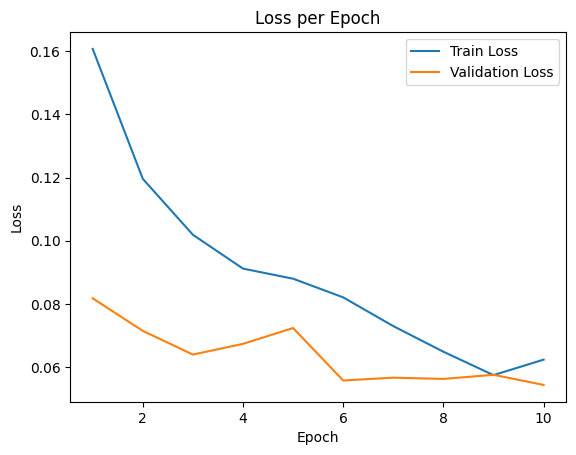

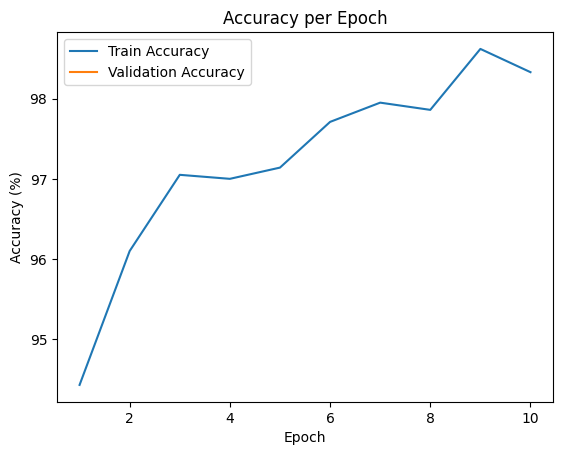

: 

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))

plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss per Epoch")
plt.show()

plt.plot(epochs, train_accuracy, label="Train Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy per Epoch")
plt.show()